In [1]:
import os
import torch

logical_cores = os.cpu_count()
physical_estimate = max(1, logical_cores // 2)

os.environ["OMP_NUM_THREADS"] = str(physical_estimate)
os.environ["MKL_NUM_THREADS"] = str(physical_estimate)

torch.set_num_threads(physical_estimate)
torch.set_num_interop_threads(physical_estimate)

print("Logical cores:", logical_cores)
print("Torch threads:", torch.get_num_threads())

Logical cores: 20
Torch threads: 10


In [4]:
from diffusers import StableDiffusionXLPipeline
from IPython.display import display
from PIL import Image

device = "cpu"
dtype = torch.float32
model_id = "stabilityai/stable-diffusion-xl-base-1.0"

pipe = StableDiffusionXLPipeline.from_pretrained(
    model_id,
    torch_dtype=dtype,
    use_safetensors=True,
    safety_checker=None,
    requires_safety_checker=False,
).to(device)

model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

c:\Users\jacob\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jacob\.cache\huggingface\hub\models--stabilityai--stable-diffusion-xl-base-1.0. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Keyword arguments {'safety_checker': None, 'requires_safety_checker': False} are not expected by StableDiffusionXLPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

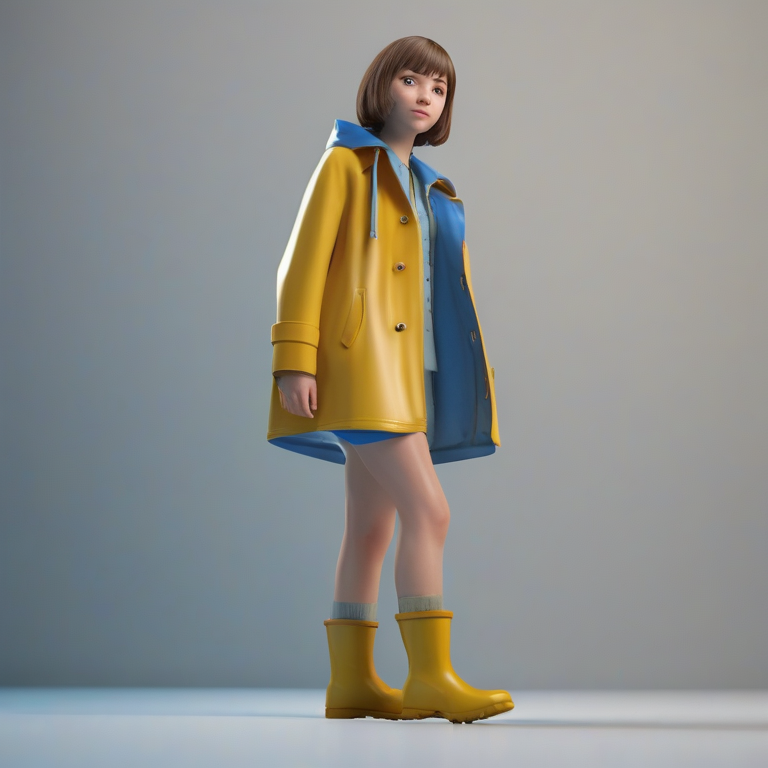

In [5]:
# Cell 3 — reference character prompt (SDXL prefers short + precise)

WIDTH, HEIGHT = 768, 768
STEPS_REF = 25
GUIDANCE_REF = 5.5

NEGATIVE = "text, watermark, logo, blurry, low quality, deformed"

REF_PROMPT = (
    "3D animated film character, full body, standing, facing camera, neutral pose. "
    "young girl, short straight medium-brown bob haircut, freckles, yellow raincoat, blue rain boots. "
    "soft cinematic lighting, natural colors, high quality render"
)

ref_image = pipe(
    prompt=REF_PROMPT,
    negative_prompt=NEGATIVE,
    width=WIDTH,
    height=HEIGHT,
    num_inference_steps=STEPS_REF,
    guidance_scale=GUIDANCE_REF,
    generator=torch.Generator(device=device).manual_seed(123),
).images[0]

display(ref_image)

Generating scene 1...


  0%|          | 0/22 [00:00<?, ?it/s]

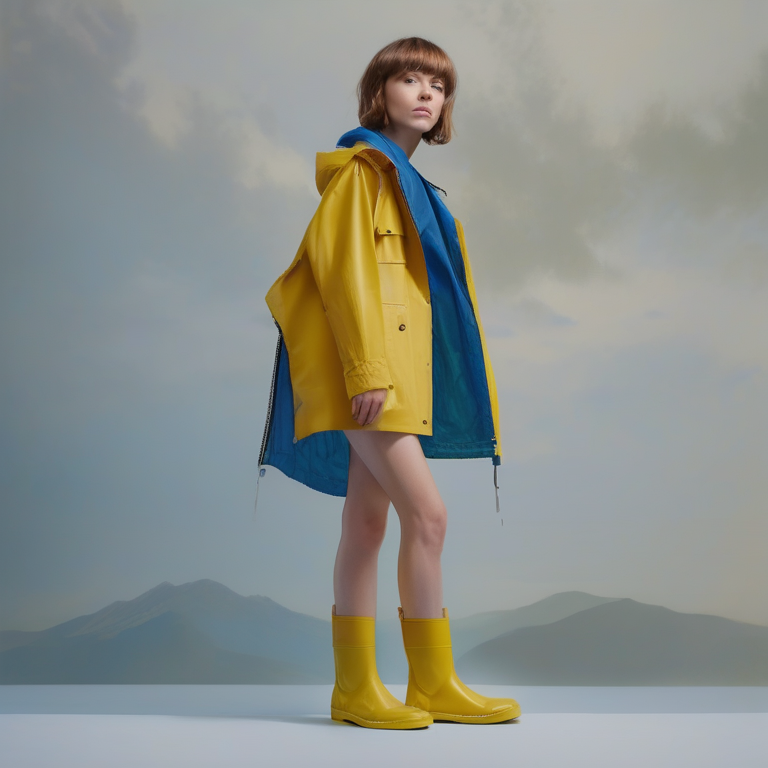

Generating scene 2...


  0%|          | 0/22 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [12]:
from diffusers import StableDiffusionXLImg2ImgPipeline

# Convert existing pipe to img2img using same weights
pipe_img2img = StableDiffusionXLImg2ImgPipeline(
    vae=pipe.vae,
    text_encoder=pipe.text_encoder,
    text_encoder_2=pipe.text_encoder_2,
    tokenizer=pipe.tokenizer,
    tokenizer_2=pipe.tokenizer_2,
    unet=pipe.unet,
    scheduler=pipe.scheduler,
).to(device)

STRENGTH = 0.75
STEPS = 30
GUIDANCE = 4.5

scene_prompts = [

    # Scene 1 — Back view walking
    "young girl with short brown bob haircut, wearing a yellow raincoat and blue rain boots, back view, walking forward through a vast golden grassy field, tall grass around her legs, distant hills on the horizon, cinematic wide landscape shot, natural outdoor lighting, her face not visible",

    # Scene 2 — Kneeling, face turned away
    "young girl with short brown bob haircut, wearing a yellow raincoat and blue rain boots, kneeling in a grassy field, examining a small white wildflower, side-back angle, her face partially turned away from camera, medium shot, soft afternoon sunlight",

    # Scene 3 — Looking down, face obscured
    "young girl with short brown bob haircut , wearing a yellow raincoat and blue rain boots, standing in a golden field, looking downward at a small white wildflower in her hands, her face mostly hidden by angle, soft golden sunset lighting, shallow depth of field",

    # Scene 4 — Side silhouette walking
    "young girl with short brown bob haircut, wearing a yellow raincoat and blue rain boots, side silhouette, walking through a golden field with the flower tucked into her raincoat pocket, sunset backlighting, wide cinematic shot, her facial features not visible"
]
generated_images = []

for i, p in enumerate(scene_prompts, 1):
    print(f"Generating scene {i}...")

    img = pipe_img2img(
        prompt=p,
        negative_prompt=NEGATIVE,
        image=ref_image,          # THIS is the identity anchor
        strength=STRENGTH,
        num_inference_steps=STEPS,
        guidance_scale=GUIDANCE,
        generator=torch.Generator(device=device).manual_seed(1000 + i),
    ).images[0]

    generated_images.append(img)
    display(img)

In [ ]:
# Cell 5 — save + 2x2 storyboard

import os
from PIL import Image
from IPython.display import display

output_dir = os.path.join(os.getcwd(), "sdxl_storyboard")
os.makedirs(output_dir, exist_ok=True)

for i, img in enumerate(generated_images, 1):
    img.save(os.path.join(output_dir, f"scene_{i}.png"))

w, h = generated_images[0].size
storyboard = Image.new("RGB", (w * 2, h * 2))
storyboard.paste(generated_images[0], (0, 0))
storyboard.paste(generated_images[1], (w, 0))
storyboard.paste(generated_images[2], (0, h))
storyboard.paste(generated_images[3], (w, h))

storyboard.save(os.path.join(output_dir, "storyboard_2x2.png"))
display(storyboard)